# SUBSIDE Backbone Overlay — base layer + projected document(s)

**Companion to:** `SUBSIDE_Science_Backbone.ipynb` and
`SUBSIDE_ScienceBackbone_Setup.ipynb`.

This notebook implements the *data overlay* pattern from Börner et al. 2012:
the broad corpus produces a stable **basemap** (the science backbone), and
any specific smaller document — an interview, a brown-bag transcript, a
regional plan, a state network policy memo — is then **projected onto that
basemap** to show where in the scientific landscape its content lives.

Two layers:

| Layer | Source | What it is |
|---|---|---|
| **Base** | `KEYWORD_GROUPS` from the main notebook (built from `.bib` keyword terms, EPH-style editable groups), mapped onto the science backbone | The reference frame. Stable across overlays. |
| **Overlay** | A single file or a folder of files (`.txt`, `.docx`, `.json`, `.md`, `.pdf`) | The corpus being *projected*. Each file is scored against the base layer's keyword groups; the resulting per-discipline weights illuminate the matching part of the backbone. |

### Compatible input formats

- Plain text (`.txt`, `.md`)
- Word documents (`.docx`)
- Brown-bag / lecture transcripts (`.json` with `text`, `chunks`, or `speakers` field — handles the meeting-recording shape automatically)
- PDF (`.pdf`, text-layer only; OCR is a separate problem)

Point `OVERLAY_PATH` at either a single file or a directory; the cell walks
the path either way.

### Why this matters

Without the basemap, any individual transcript looks isolated. Projected onto
the backbone, you can see at a glance: *this brown bag was 60% Earth Sciences
/ 25% Engineering / 10% Social Science / 5% other*, and you can compare two
brown bags side-by-side using the same reference frame. The basemap is what
makes the comparison meaningful.

---

## 1. Setup


In [13]:
import os
from pathlib import Path
import os, json, re
from pathlib import Path
import pandas as pd
import numpy as np
import os, json, re
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np

# ── TACC base path (Lonestar6) ───────────────────────────────────────
# Single source of truth — change this one line if you move the folder.
WORK_BASE = Path(os.environ["WORK"]) / "cookbooks" / "SUBSIDE SciMap"
# Equivalent absolute form, if $WORK isn't set:
# WORK_BASE = Path("/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap")

# Where the base backbone JSON lives (produced by the setup notebook)
BACKBONE_JSON_PATH = WORK_BASE / "ScienceBackboneResults" / "science_backbone.json"

# Most recent EPH-style keyword groups JSON (produced by main notebook §9)
_kw_dir = WORK_BASE / "ScienceBackboneResults"
_kw_matches = sorted(_kw_dir.glob("keyword_groups_*.json"), reverse=True) \
              if _kw_dir.exists() else []
KEYWORD_GROUPS_PATH = _kw_matches[0] if _kw_matches else None

# Where overlay files live (folder of interviews, brown-bags, plans, etc.)
OVERLAY_PATH = WORK_BASE / "CollectionForOverlays"

# Outputs land alongside the backbone, not in ephemeral Tapis scratch
OUTPUT_DIR = WORK_BASE / "OverlayResults"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Work base       : {WORK_BASE}")
print(f"Backbone JSON   : {BACKBONE_JSON_PATH}  (exists = {BACKBONE_JSON_PATH.exists()})")
print(f"Keyword groups  : {KEYWORD_GROUPS_PATH}")
print(f"Overlay path    : {OVERLAY_PATH}  (exists = {OVERLAY_PATH.exists()})")
print(f"Output dir      : {OUTPUT_DIR}")

Work base       : /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap
Backbone JSON   : /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults/science_backbone.json  (exists = True)
Keyword groups  : /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/ScienceBackboneResults/keyword_groups_20260512_063128.json
Overlay path    : /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/CollectionForOverlays  (exists = True)
Output dir      : /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults


In [14]:
# Dependency check
import sys, subprocess, importlib

def _ensure(pkg, import_name=None):
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for _p, _m in [("python-docx", "docx"),
               ("pypdf",       "pypdf"),
               ("plotly",      "plotly"),
               ("networkx",    "networkx")]:
    _ensure(_p, _m)

from docx import Document as _Docx
try:
    from pypdf import PdfReader as _PdfReader
    PDF_OK = True
except ImportError:
    PDF_OK = False

print("✓ Imports complete")


✓ Imports complete


## 2. Load the base layer

The base layer is the EPH-style `KEYWORD_GROUPS` dict combined with the
science backbone the keyword groups map onto. Three resolution paths:

| Path | When it's used |
|---|---|
| Load `science_backbone.json` + `keyword_groups_*.json` from prior runs | Recommended. You already ran the setup + main notebooks. |
| Inline `KEYWORD_GROUPS` (same defaults as the main notebook §4) + load `science_backbone.json` | You have the backbone but no exported keyword groups. |
| Inline both | First-time use, no prior runs to draw from. The backbone here is the SUBSIDE-tuned inline fallback. |


In [15]:
# ── Inline KEYWORD_GROUPS — mirror of main notebook §4 ────────────────
# This is the EPH _GROUP_REGISTRY pattern: each group is a list of synonyms /
# variants. A document matches the group if ANY of its terms appears
# (substring, case-insensitive). Edit freely.
INLINE_KEYWORD_GROUPS = {
    "Subsidence":     ["subsidence", "land subsidence", "ground subsidence",
                       "settlement", "compaction", "consolidation"],
    "Uplift_Rebound": ["uplift", "rebound", "heave", "swelling"],
    "Groundwater":    ["groundwater", "aquifer", "aquifers", "pumping",
                       "withdrawal", "depletion", "drawdown", "phreatic"],
    "OilGas":         ["oil", "gas", "petroleum", "hydrocarbon", "reservoir",
                       "extraction", "production", "co2 storage", "sequestration"],
    "Mining":         ["mining", "mine", "coal mine", "underground mine",
                       "longwall", "subsurface mining"],
    "Tectonic":       ["tectonic", "fault", "faulting", "fault slip", "seismic"],
    "Sediment":       ["sediment", "sedimentation", "deltaic", "delta",
                       "alluvial", "natural compaction"],
    "InSAR":          ["insar", "interferometric", "interferogram", "psinsar",
                       "persistent scatterer", "sentinel-1", "alos", "envisat"],
    "GNSS_GPS":       ["gnss", "gps", "global positioning", "continuous gps",
                       "cgps", "geodetic"],
    "LiDAR":          ["lidar", "light detection and ranging", "airborne lidar",
                       "topobathymetric"],
    "Leveling":       ["leveling", "levelling", "extensometer", "extensometers"],
    "Remote_Sensing": ["remote sensing", "satellite", "earth observation",
                       "sar", "synthetic aperture radar"],
    "Coastal":        ["coastal", "coast", "shoreline", "tidal", "estuary",
                       "estuaries", "salt marsh", "sea level", "sea-level rise"],
    "Urban":          ["urban", "city", "cities", "metropolitan", "infrastructure"],
    "Flood":          ["flood", "flooding", "inundation", "storm surge"],
    "Modeling":       ["model", "modeling", "simulation", "physics-based",
                       "numerical model", "finite element", "finite-element",
                       "modflow"],
    "MachineLearning":["machine learning", "deep learning", "neural network",
                       "random forest", "lstm", "convolutional"],
    "Policy_Decision":["policy", "governance", "stakeholder", "decision support",
                       "management", "regulation", "groundwater management area",
                       "gma", "groundwater conservation district", "gcd"],
}

# Try to load saved keyword groups, fall back to inline
KEYWORD_GROUPS = None
if KEYWORD_GROUPS_PATH and KEYWORD_GROUPS_PATH.exists():
    try:
        with open(KEYWORD_GROUPS_PATH) as fh:
            KEYWORD_GROUPS = json.load(fh)
        print(f"✓ Loaded {len(KEYWORD_GROUPS)} keyword groups from {KEYWORD_GROUPS_PATH.name}")
    except Exception as e:
        print(f"  ⚠ Could not parse {KEYWORD_GROUPS_PATH}: {type(e).__name__}: {e}")

if KEYWORD_GROUPS is None:
    KEYWORD_GROUPS = INLINE_KEYWORD_GROUPS
    print(f"✓ Using inline KEYWORD_GROUPS ({len(KEYWORD_GROUPS)} groups)")

print()
for k, v in KEYWORD_GROUPS.items():
    sample = ", ".join(v[:4]) + ("…" if len(v) > 4 else "")
    print(f"   {k:18s} {len(v):2d} terms — {sample}")


✓ Loaded 18 keyword groups from keyword_groups_20260512_063128.json

   Subsidence          6 terms — subsidence, land subsidence, ground subsidence, settlement…
   Uplift_Rebound      4 terms — uplift, rebound, heave, swelling
   Groundwater         8 terms — groundwater, aquifer, aquifers, pumping…
   OilGas              9 terms — oil, gas, petroleum, hydrocarbon…
   Mining              6 terms — mining, mine, coal mine, underground mine…
   Tectonic            5 terms — tectonic, fault, faulting, fault slip…
   Sediment            6 terms — sediment, sedimentation, deltaic, delta…
   InSAR               8 terms — insar, interferometric, interferogram, psinsar…
   GNSS_GPS            6 terms — gnss, gps, global positioning, continuous gps…
   LiDAR               4 terms — lidar, light detection and ranging, airborne lidar, topobathymetric
   Leveling            4 terms — leveling, levelling, extensometer, extensometers
   Remote_Sensing      5 terms — remote sensing, satellite, earth

In [16]:
# ── Load the science backbone JSON, or fall back to an inline scaffold ──
SCIENCE_BACKBONE = None
BACKBONE_SOURCE  = None

if BACKBONE_JSON_PATH.exists():
    try:
        with open(BACKBONE_JSON_PATH) as fh:
            _payload = json.load(fh)
        _selected = _payload.get("selected_layer") or "merged"
        _layers   = _payload.get("layers", {})
        _candidate = _layers.get(_selected) or _layers.get("merged") or _layers.get("ucsd")
        if _candidate:
            SCIENCE_BACKBONE = {d: {k: v for k, v in node.items()
                                    if not str(k).startswith("_")}
                                for d, node in _candidate.items()}
            BACKBONE_SOURCE = (f"science_backbone.json (layer='{_selected}', "
                               f"produced {_payload.get('produced_at','?')[:10]})")
    except Exception as e:
        print(f"  ⚠ Could not load {BACKBONE_JSON_PATH}: {type(e).__name__}: {e}")

if SCIENCE_BACKBONE is None:
    # Compact SUBSIDE-tuned fallback — same shape as the main notebook §5 Tier 3
    SCIENCE_BACKBONE = {
        "Earth Sciences": {
            "subdisciplines": ["Hydrology", "Hydrogeology", "Sedimentology",
                               "Geomorphology", "Tectonics", "Coastal Science",
                               "Remote Sensing"],
            "terms": ["groundwater","aquifer","subsidence","compaction","sediment",
                      "coastal","insar","gnss","lidar","remote sensing",
                      "geodetic","sea level","fault","tectonic"]},
        "Chemical, Mechanical, & Civil Engineering": {
            "subdisciplines": ["Geotechnical Engineering","Petroleum Engineering",
                               "Mining Engineering","Civil Engineering"],
            "terms": ["geotechnical","oil","gas","petroleum","mining","coal",
                      "civil","foundation","reservoir","co2"]},
        "Electrical Engineering & Computer Science": {
            "subdisciplines": ["Machine Learning","Signal Processing"],
            "terms": ["machine learning","deep learning","neural network",
                      "lstm","convolutional","algorithm","signal processing"]},
        "Social Sciences": {
            "subdisciplines": ["Public Policy","Decision Science","Geography"],
            "terms": ["policy","governance","stakeholder","decision support",
                      "regulation","management","gma","gcd","groundwater management"]},
        "Math & Physics": {
            "subdisciplines": ["Mathematics","Statistics","Geophysics"],
            "terms": ["mathematics","statistics","numerical","simulation",
                      "modeling","geophysics","equation","model"]},
    }
    BACKBONE_SOURCE = "inline SUBSIDE-tuned fallback (no science_backbone.json found)"

print(f"✓ Backbone source: {BACKBONE_SOURCE}")
print(f"  {len(SCIENCE_BACKBONE)} domains:")
for d, node in SCIENCE_BACKBONE.items():
    print(f"    · {d:55s} {len(node.get('subdisciplines',[])):2d} subs · "
          f"{len(node.get('terms',[])):3d} terms")


✓ Backbone source: science_backbone.json (layer='merged', produced 2026-05-11)
  12 domains:
    · Biology                                                 68 subs · 159 terms
    · Biotechnology                                           11 subs ·  33 terms
    · Medical Specialties                                     91 subs · 200 terms
    · Chemical, Mechanical, & Civil Engineering               101 subs · 255 terms
    · Chemistry                                               57 subs · 148 terms
    · Earth Sciences                                          47 subs · 152 terms
    · Electrical Engineering & Computer Science               82 subs · 215 terms
    · Brain Research                                          28 subs ·  63 terms
    · Humanities                                              51 subs · 132 terms
    · Math & Physics                                          53 subs · 152 terms
    · Health Professionals                                    70 subs · 152 terms
    

### 2.1 Map keyword groups → backbone domains (base layer)

Same mapper as the main notebook's §6. This produces `group_mapping_df` — the
table that says which backbone domain each keyword group primarily belongs to.


In [17]:
def map_terms_to_backbone(terms, backbone, top_n=3):
    terms_l = [str(t).lower() for t in terms]
    hits = []
    for domain, node in backbone.items():
        subs       = node.get("subdisciplines") or ["General"]
        node_terms = node.get("terms") or [domain.lower()]
        for sub in subs:
            score = sum(1 for t in terms_l
                        if any(str(kw).lower() in t for kw in node_terms))
            if score > 0:
                hits.append((domain, sub, score))
    if not hits:
        return [("Uncategorized", "General", 0)]
    return sorted(hits, key=lambda x: -x[2])[:top_n]


group_mappings = []
for name, terms in KEYWORD_GROUPS.items():
    mapping = map_terms_to_backbone(terms, SCIENCE_BACKBONE)
    group_mappings.append({
        "group":            name,
        "terms":            terms,
        "primary_domain":   mapping[0][0],
        "backbone_mapping": mapping,
    })

group_mapping_df = pd.DataFrame(group_mappings)
print("Base-layer keyword group → primary backbone domain:")
print(group_mapping_df[["group","primary_domain"]].to_string(index=False))


Base-layer keyword group → primary backbone domain:
          group                            primary_domain
     Subsidence                            Earth Sciences
 Uplift_Rebound                             Uncategorized
    Groundwater                            Earth Sciences
         OilGas Chemical, Mechanical, & Civil Engineering
         Mining Chemical, Mechanical, & Civil Engineering
       Tectonic                            Earth Sciences
       Sediment                            Earth Sciences
          InSAR                            Earth Sciences
       GNSS_GPS                            Earth Sciences
          LiDAR                            Earth Sciences
       Leveling                            Earth Sciences
 Remote_Sensing                            Earth Sciences
        Coastal                            Earth Sciences
          Urban                           Social Sciences
          Flood                             Uncategorized
       Modeling     

## 3. Select the overlay corpus

Point `OVERLAY_PATH` (set in §1) at either:
- a **single file** — one interview, one brown-bag transcript, one regional plan
- a **directory** — multiple files treated as one overlay corpus (e.g., all the brown bags)

The loader handles `.txt`, `.md`, `.docx`, `.json` (including brown-bag
`text` / `chunks` / `speakers` shapes), and `.pdf` (text layer only).

If you want to narrow the directory to specific files, edit
`OVERLAY_GLOB_PATTERNS` below. Default `["*"]` matches everything; change to
e.g. `["*Brown_Bag*", "*BrownBag*"]` to keep only brown-bag JSONs.


In [18]:
# ── File loader (adapted from the streamlined V6 Cell 7 pattern) ──────
OVERLAY_GLOB_PATTERNS = ["*"]   # narrow this to filter, e.g. ["*Brown_Bag*"]
OVERLAY_MAX_FILES     = 200     # safety cap
OVERLAY_MIN_CHARS     = 200     # skip near-empty files


def _extract_json_text(data):
    '''Pull the most informative text field from a parsed JSON structure.'''
    if isinstance(data, str):
        return data
    if not isinstance(data, dict):
        return json.dumps(data)
    # Brown-bag MeetingRecording shape: top-level 'text' is the full transcript
    if isinstance(data.get("text"), str) and len(data["text"]) > 100:
        return data["text"]
    # Chunked transcripts: 'chunks' is a list of {timestamp, text}
    if isinstance(data.get("chunks"), list) and data["chunks"]:
        parts = [str(c.get("text", "")) for c in data["chunks"]
                 if isinstance(c, dict)]
        if any(parts):
            return " ".join(parts)
    # Speaker-based transcripts: 'speakers' is a list of {speaker, text}
    if isinstance(data.get("speakers"), list) and data["speakers"]:
        parts = [str(s.get("text", "")) for s in data["speakers"]
                 if isinstance(s, dict)]
        if any(parts):
            return " ".join(parts)
    # Generic 'content' field
    if isinstance(data.get("content"), str):
        return data["content"]
    return json.dumps(data)


def load_overlay_file(filepath: Path):
    '''Return (text, source_kind) or (None, reason) if unsupported / empty.'''
    suf = filepath.suffix.lower()
    try:
        if suf in (".txt", ".md"):
            return filepath.read_text(encoding="utf-8", errors="replace"), suf[1:]
        if suf == ".json":
            with open(filepath, "r", encoding="utf-8", errors="replace") as fh:
                data = json.load(fh)
            return _extract_json_text(data), "json"
        if suf == ".docx":
            doc = _Docx(str(filepath))
            txt = "\n".join(p.text for p in doc.paragraphs)
            return txt, "docx"
        if suf == ".pdf" and PDF_OK:
            reader = _PdfReader(str(filepath))
            txt = "\n".join((p.extract_text() or "") for p in reader.pages)
            return txt, "pdf"
        return None, f"unsupported format ({suf})"
    except Exception as e:
        return None, f"{type(e).__name__}: {e}"


def load_overlay_corpus(path: Path):
    '''Walk a file or directory and return {doc_name: text}.'''
    docs = {}
    skipped = []
    candidate_files = []
    if path.is_file():
        candidate_files = [path]
    elif path.is_dir():
        for pat in OVERLAY_GLOB_PATTERNS:
            candidate_files.extend(sorted(path.glob(pat)))
        # Dedupe while preserving order
        seen = set(); uniq = []
        for f in candidate_files:
            if f not in seen and f.is_file():
                seen.add(f); uniq.append(f)
        candidate_files = uniq
        candidate_files = candidate_files[:OVERLAY_MAX_FILES]
    else:
        return docs, [(str(path), "path does not exist")]

    for f in candidate_files:
        if f.name.startswith(".") or f.name.startswith("~$"):
            continue
        if "checkpoint" in f.name.lower():
            continue
        text, kind = load_overlay_file(f)
        if text is None:
            skipped.append((f.name, kind))
            continue
        if len(text.strip()) < OVERLAY_MIN_CHARS:
            skipped.append((f.name, f"too short ({len(text.strip())} chars)"))
            continue
        docs[f.stem] = text
    return docs, skipped


overlay_docs, overlay_skipped = load_overlay_corpus(OVERLAY_PATH)
print(f"✓ Loaded {len(overlay_docs)} overlay document(s) from {OVERLAY_PATH}")
for name, txt in overlay_docs.items():
    print(f"   · {name:55s} {len(txt):>8,} chars")
if overlay_skipped:
    print(f"\nSkipped {len(overlay_skipped)} file(s):")
    for name, reason in overlay_skipped[:10]:
        print(f"   · {name}: {reason}")


✓ Loaded 16 overlay document(s) from /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/CollectionForOverlays
   · Subsidence_Brown_Bag_Date-20230914_120029-MeetingRecording   41,678 chars
   · Subsidence_Brown_Bags_Date-03092028_MeetingRecording      23,494 chars
   · Subsidence_Brown_Bags_Date-20230209_120036-MeetingRecording   45,862 chars
   · Subsidence_Brown_Bags_Date-20230413_120246-MeetingRecording   40,333 chars
   · Subsidence_Brown_Bags_Date-20230511_120131-MeetingRecording   55,073 chars
   · Subsidence_Brown_Bags_Date-20230608_120214-MeetingRecording   27,597 chars
   · Subsidence_Brown_Bags_Date-20230713_120313-MeetingRecording   47,595 chars
   · Subsidence_Brown_Bags_Date-20230810_120227-MeetingRecording   41,741 chars
   · Subsidence_Brown_Bags_Date-20231012_120051-MeetingRecording   50,123 chars
   · Subsidence_Lunch_Time_Speaker_Series-20241114_200816-Meeting_Recording   50,095 chars
   · Subsidence_Lunch_Time_Speaker_Series_20240208_115934_MeetingRecording   44,667 cha

## 4. Project the overlay onto the backbone

For each overlay document and each keyword group, count the term occurrences
(case-insensitive, word-boundary regex). Then aggregate up:

1. **Per (document, group)** raw counts → `overlay_doc_group_df`
2. **Per group** rolled up across all overlay docs → `overlay_group_totals`
3. **Per backbone domain** weighted by the group → backbone mapping → `overlay_domain_totals`
4. **Per backbone subdiscipline** weighted by the group → backbone mapping → `overlay_sub_totals`

The base layer (full-corpus group → domain mapping from §2.1) stays fixed;
what changes is the *intensity* with which each part of the backbone lights up.


In [19]:
def count_group_in_text(text, group_terms):
    '''Count occurrences of any term in group_terms within text. Word-boundary.'''
    text_l = text.lower()
    total = 0
    for term in group_terms:
        # Multi-word terms: substring search (avoids regex escaping nightmares)
        # Single-word terms: word-boundary regex
        t = term.lower()
        if " " in t or "-" in t:
            total += text_l.count(t)
        else:
            total += len(re.findall(rf"\b{re.escape(t)}\b", text_l))
    return total


# Per (doc, group) counts
rows = []
for doc_name, text in overlay_docs.items():
    n_chars = len(text)
    n_words = len(text.split())
    for group, terms in KEYWORD_GROUPS.items():
        c = count_group_in_text(text, terms)
        rows.append({"doc": doc_name, "group": group,
                     "count": c, "doc_n_words": n_words,
                     "per_1k_words": round(1000 * c / max(n_words, 1), 2)})
overlay_doc_group_df = pd.DataFrame(rows)

# Per-group totals (across all overlay docs)
overlay_group_totals = (overlay_doc_group_df
                        .groupby("group")["count"].sum()
                        .reset_index()
                        .sort_values("count", ascending=False))

# Per-domain totals: each group contributes its count to its mapping's domains,
# weighted by the (domain, sub, score) in the backbone_mapping. We split a
# group's count proportionally across its top backbone targets.
domain_weights = defaultdict(float)
sub_weights = defaultdict(float)
for _, grow in group_mapping_df.iterrows():
    g = grow["group"]
    mapping = grow["backbone_mapping"]
    g_count = float(overlay_group_totals.set_index("group")["count"].get(g, 0))
    if g_count <= 0 or not mapping:
        continue
    total_score = sum(s for _, _, s in mapping) or 1.0
    for domain, sub, score in mapping:
        w = g_count * (score / total_score)
        domain_weights[domain] += w
        sub_weights[(domain, sub)] += w

overlay_domain_totals = (pd.DataFrame(
    [{"domain": d, "weight": w} for d, w in domain_weights.items()])
    .sort_values("weight", ascending=False).reset_index(drop=True))

overlay_sub_totals = (pd.DataFrame(
    [{"domain": d, "subdiscipline": s, "weight": w}
     for (d, s), w in sub_weights.items()])
    .sort_values("weight", ascending=False).reset_index(drop=True))

print("Top 10 keyword groups by overlay match count:")
print(overlay_group_totals.head(10).to_string(index=False))
print()
print("Domain weights (overlay projected onto base backbone):")
print(overlay_domain_totals.to_string(index=False))


Top 10 keyword groups by overlay match count:
         group  count
    Subsidence   1013
   Groundwater    545
       Coastal    467
      Modeling    301
      GNSS_GPS    239
         Urban    161
        OilGas    139
Remote_Sensing    121
      Leveling    119
         InSAR    118

Domain weights (overlay projected onto base backbone):
                                   domain  weight
                           Earth Sciences  2698.0
                           Math & Physics   301.0
                          Social Sciences   255.0
Chemical, Mechanical, & Civil Engineering   150.0
Electrical Engineering & Computer Science     4.0
                            Uncategorized     0.0


## 5. Overlay visualization

Same Klavans/Boyack radial layout as the main notebook's §7, but recolored to
show the overlay's projection:

- **Domains** retain their UCSD-published colors (so you can recognize the
  reference frame), but each domain's **opacity scales with its overlay
  weight** — heavy-weight domains pop, light-weight domains fade back.
- **Subdisciplines** are heat-colored by their overlay weight (white → brand orange).
- **Keyword group diamonds** are sized by overlay match count instead of base
  corpus match count. Groups with zero overlay matches drop out entirely.
- **Outer ring**: each overlay document becomes a small node connected by a
  thin gray edge to the keyword groups it activates. Hover for per-group counts.


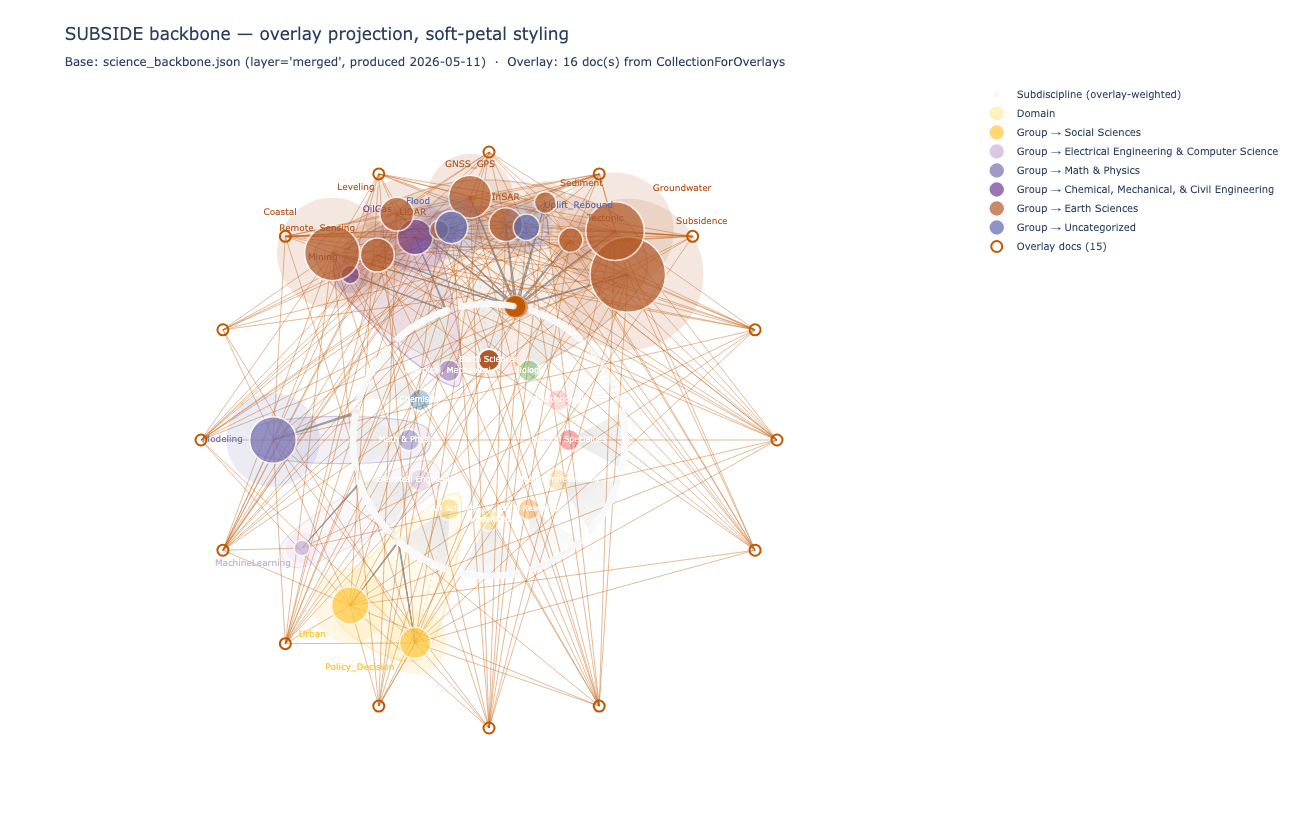

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_backbone.html


In [21]:
"""
Overlay §5 replacement v2 — soft-petal styling matched to the main notebook.

Same elegant treatment as section_7_replacement_v2.py (filled hull "petals"
per domain, circles with a glow instead of diamonds, spline-curved outlines),
adapted to the overlay notebook's data model:

  - Keyword group sizes come from overlay_group_totals["count"], NOT from
    group_mapping_df["n_matches"] (which doesn't exist here).
  - Subdiscipline dots are heat-colored by overlay weight (gray → TACC orange),
    not domain color.
  - Domain marker opacity scales with overlay weight, so domains the overlay
    barely touches fade to the background.
  - Outer ring of overlay-document nodes is retained.
  - Inactive keyword groups (zero overlay matches) are dropped entirely.

Drops into the §5 cell of SUBSIDE_Backbone_Overlay.ipynb. Same inputs:
SCIENCE_BACKBONE, group_mapping_df, overlay_docs, overlay_doc_group_df,
overlay_group_totals, overlay_domain_totals, overlay_sub_totals,
OUTPUT_DIR, BACKBONE_SOURCE, OVERLAY_PATH.
"""

import math
from collections import defaultdict
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px

# ── 1. Klavans/Boyack-inspired circular ordering ──────────────────────
KLAVANS_BOYACK_ORDER = [
    "Humanities", "Social Sciences",
    "Electrical Engineering & Computer Science",
    "Math & Physics", "Chemistry",
    "Chemical, Mechanical, & Civil Engineering",
    "Earth Sciences", "Biology", "Biotechnology",
    "Infectious Disease", "Medical Specialties",
    "Health Professionals", "Brain Research",
]
UCSD_HEX = {
    "Math & Physics":                                "#7570B3",
    "Chemistry":                                     "#1F78B4",
    "Earth Sciences":                                "#B15928",
    "Biology":                                       "#33A02C",
    "Biotechnology":                                 "#FB9A99",
    "Infectious Disease":                            "#A6CEE3",
    "Medical Specialties":                           "#E31A1C",
    "Health Professionals":                          "#FDBF6F",
    "Brain Research":                                "#FF7F00",
    "Electrical Engineering & Computer Science":     "#CAB2D6",
    "Chemical, Mechanical, & Civil Engineering":     "#6A3D9A",
    "Social Sciences":                               "#FFC83D",
    "Humanities":                                    "#FFE066",
}
TACC_ORANGE = "#BF5700"   # heat color for overlay-weighted subdisciplines

domains_in_backbone = list(SCIENCE_BACKBONE.keys())
ordered_domains = (
    [d for d in KLAVANS_BOYACK_ORDER if d in domains_in_backbone] +
    [d for d in domains_in_backbone if d not in KLAVANS_BOYACK_ORDER]
)

# ── 2. Layout: domains → subdisciplines → keyword groups → overlay docs
R_DOMAIN   = 1.0
R_SUB      = 1.7
R_GROUP    = 2.7
R_OVERLAY  = 3.6
ARC_SUBS   = math.radians(24)
ARC_GROUPS = math.radians(20)

pos = {}
domain_angle = {}
for i, d in enumerate(ordered_domains):
    theta = -math.pi/2 - 2 * math.pi * i / max(len(ordered_domains), 1)
    domain_angle[d] = theta
    pos[d] = (R_DOMAIN * math.cos(theta), R_DOMAIN * math.sin(theta))


def _fan(base, n, arc, r):
    if n <= 0: return []
    if n == 1: return [(r * math.cos(base), r * math.sin(base))]
    return [(r * math.cos(base - arc/2 + (j/(n-1)) * arc),
             r * math.sin(base - arc/2 + (j/(n-1)) * arc)) for j in range(n)]


for d in ordered_domains:
    subs = SCIENCE_BACKBONE[d].get("subdisciplines") or ["General"]
    for sub, xy in zip(subs, _fan(domain_angle[d], len(subs), ARC_SUBS, R_SUB)):
        pos[f"{d} :: {sub}"] = xy

# Only keep keyword groups with non-zero overlay matches
active_groups = set(overlay_group_totals[overlay_group_totals["count"] > 0]["group"])
group_by_domain = defaultdict(list)
for _, row in group_mapping_df.iterrows():
    if row["group"] in active_groups:
        group_by_domain[row["primary_domain"]].append(row["group"])

unmatched = [d for d in group_by_domain if d not in domain_angle]
for k, ud in enumerate(unmatched):
    domain_angle[ud] = math.pi/2 + (k - (len(unmatched)-1)/2) * math.radians(10)

for d, groups in group_by_domain.items():
    n = len(groups)
    arc = max(ARC_GROUPS, math.radians(8 * n))
    coords = _fan(domain_angle[d], n, arc, R_GROUP)
    if n > 3:
        for j in range(n):
            stagger = 0.35 if (j % 2 == 1) else 0.0
            x, y = coords[j]; ro = math.hypot(x, y); sc = (ro + stagger) / ro
            coords[j] = (x * sc, y * sc)
    for g, xy in zip(groups, coords):
        pos[g] = xy

# Overlay documents on outermost ring
overlay_doc_names = list(overlay_docs.keys())
n_ov = len(overlay_doc_names)
for j, doc in enumerate(overlay_doc_names):
    th = -math.pi/2 - 2 * math.pi * j / max(n_ov, 1)
    pos[f"OVERLAY::{doc}"] = (R_OVERLAY * math.cos(th), R_OVERLAY * math.sin(th))

# ── 3. Helpers ────────────────────────────────────────────────────────
def _hex_to_rgba(color, alpha):
    """Convert hex or rgb(...) to rgba string."""
    s = str(color).strip()
    if s.startswith("rgb"):
        inner = s[s.index("(")+1:s.rindex(")")]
        parts = [p.strip() for p in inner.split(",")]
        r, g, b = int(float(parts[0])), int(float(parts[1])), int(float(parts[2]))
        return f"rgba({r},{g},{b},{alpha})"
    h = s.lstrip("#")
    if len(h) == 3:
        h = "".join(c * 2 for c in h)
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def _convex_hull(points):
    """Andrew's monotone chain. CCW hull, or short list if ≤2 unique points."""
    pts = sorted(set(points))
    if len(pts) < 2:
        return pts
    def cross(o, a, b):
        return (a[0]-o[0]) * (b[1]-o[1]) - (a[1]-o[1]) * (b[0]-o[0])
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
    return lower[:-1] + upper[:-1]


def _inflate_hull(hull_pts, margin=0.20):
    if len(hull_pts) < 2:
        return hull_pts
    cx = sum(p[0] for p in hull_pts) / len(hull_pts)
    cy = sum(p[1] for p in hull_pts) / len(hull_pts)
    out = []
    for x, y in hull_pts:
        dx, dy = x - cx, y - cy
        dist = math.hypot(dx, dy) or 1.0
        out.append((x + dx/dist * margin, y + dy/dist * margin))
    return out


def heat_color(weight, vmax, base="#f5f5f5", hot=TACC_ORANGE):
    """Linear interpolation from cool light gray to TACC orange."""
    t = min(1.0, weight / vmax) if vmax > 0 else 0.0
    def _h(c): return tuple(int(c[i:i+2], 16) for i in (1, 3, 5))
    a, b = _h(base), _h(hot)
    return "#{:02X}{:02X}{:02X}".format(*[int(a[k] + (b[k]-a[k]) * t) for k in range(3)])


QUAL = px.colors.qualitative.Bold + px.colors.qualitative.Vivid
def domain_color(d):
    if d in UCSD_HEX:
        return UCSD_HEX[d]
    idx = (ordered_domains + unmatched).index(d) if d in ordered_domains or d in unmatched else 0
    return QUAL[idx % len(QUAL)]
DOMAIN_COLORS = {d: domain_color(d) for d in ordered_domains + unmatched}
DOMAIN_COLORS.setdefault("Uncategorized", "#9a9a9a")

# ── 4. Build graph for edges + node metadata ──────────────────────────
G = nx.Graph()
for d in ordered_domains:
    G.add_node(d, kind="domain")
    for sub in SCIENCE_BACKBONE[d].get("subdisciplines") or ["General"]:
        sid = f"{d} :: {sub}"
        G.add_node(sid, kind="subdiscipline", label=sub, parent=d)
        G.add_edge(d, sid, edge_kind="scaffold")
for _, row in group_mapping_df.iterrows():
    if row["group"] not in active_groups:
        continue
    g = row["group"]
    G.add_node(g, kind="group",
               primary_domain=row["primary_domain"],
               overlay_count=int(overlay_group_totals
                                 .set_index("group")["count"].get(g, 0)))
    for d, s, sc in row["backbone_mapping"]:
        sid = f"{d} :: {s}"
        if sid in G:
            G.add_edge(g, sid, edge_kind="hit", weight=float(sc))
    if row["primary_domain"] in G:
        G.add_edge(g, row["primary_domain"], edge_kind="anchor")

overlay_doc_groups = (overlay_doc_group_df[overlay_doc_group_df["count"] > 0]
                      .groupby(["doc", "group"])["count"].sum().reset_index())
for _, r in overlay_doc_groups.iterrows():
    od = f"OVERLAY::{r['doc']}"
    g = r["group"]
    G.add_node(od, kind="overlay_doc", label=r["doc"])
    if g in G:
        G.add_edge(od, g, edge_kind="overlay", weight=float(r["count"]))

# Overlay weight lookups
max_dom_w = max(overlay_domain_totals["weight"].max(), 1.0) if len(overlay_domain_totals) else 1.0
dom_weight = {r["domain"]: r["weight"] for _, r in overlay_domain_totals.iterrows()}
max_sub_w = max(overlay_sub_totals["weight"].max(), 1.0) if len(overlay_sub_totals) else 1.0
sub_weight = {(r["domain"], r["subdiscipline"]): r["weight"]
              for _, r in overlay_sub_totals.iterrows()}

# ── 5. Draw ───────────────────────────────────────────────────────────
traces = []

# (a) Domain "petals" — convex hull of (domain_node, *its_keyword_groups)
for d in ordered_domains + unmatched:
    groups = group_by_domain.get(d, [])
    if not groups:
        continue
    pts = ([pos[d]] if d in pos else []) + [pos[g] for g in groups if g in pos]
    if len(pts) < 2:
        continue
    hull = _convex_hull(pts)
    hull = _inflate_hull(hull, margin=0.22)
    if len(hull) == 2:
        (x1, y1), (x2, y2) = hull
        dx, dy = x2 - x1, y2 - y1
        ll = math.hypot(dx, dy) or 1.0
        nx_, ny_ = -dy/ll * 0.15, dx/ll * 0.15
        hull = [(x1+nx_, y1+ny_), (x2+nx_, y2+ny_),
                (x2-nx_, y2-ny_), (x1-nx_, y1-ny_)]
    xs = [p[0] for p in hull] + [hull[0][0]]
    ys = [p[1] for p in hull] + [hull[0][1]]
    color = DOMAIN_COLORS.get(d, "#888")
    traces.append(go.Scatter(
        x=xs, y=ys, mode="lines",
        line=dict(color=_hex_to_rgba(color, 0.35), width=1.2, shape="spline"),
        fill="toself", fillcolor=_hex_to_rgba(color, 0.10),
        hoverinfo="skip", showlegend=False))

# (b) Edges
def edge_xy(kind):
    xs, ys = [], []
    for u, v, ed in G.edges(data=True):
        if ed.get("edge_kind") != kind:
            continue
        ux, uy = pos.get(u, (0, 0)); vx, vy = pos.get(v, (0, 0))
        xs += [ux, vx, None]; ys += [uy, vy, None]
    return xs, ys

sx, sy = edge_xy("scaffold")
traces.append(go.Scatter(x=sx, y=sy, mode="lines",
                         line=dict(color="#e8e8e8", width=0.5),
                         hoverinfo="none", showlegend=False))
ax_, ay = edge_xy("anchor")
traces.append(go.Scatter(x=ax_, y=ay, mode="lines",
                         line=dict(color="#cccccc", width=0.5, dash="dot"),
                         hoverinfo="none", showlegend=False))
hx, hy = edge_xy("hit")
traces.append(go.Scatter(x=hx, y=hy, mode="lines",
                         line=dict(color="#9a9a9a", width=1.0),
                         hoverinfo="none", showlegend=False))
ox, oy = edge_xy("overlay")
traces.append(go.Scatter(x=ox, y=oy, mode="lines",
                         line=dict(color=_hex_to_rgba(TACC_ORANGE, 0.45), width=0.9),
                         hoverinfo="none", showlegend=False))

# (c) Subdisciplines — heat-colored dots, sized by overlay weight
sub_nodes = [n for n, d in G.nodes(data=True) if d.get("kind") == "subdiscipline"]
sub_colors = [heat_color(sub_weight.get((G.nodes[n]["parent"], G.nodes[n]["label"]), 0),
                         max_sub_w) for n in sub_nodes]
sub_sizes = [6 + 16 * (sub_weight.get((G.nodes[n]["parent"], G.nodes[n]["label"]), 0) / max_sub_w)
             for n in sub_nodes]
traces.append(go.Scatter(
    x=[pos[n][0] for n in sub_nodes], y=[pos[n][1] for n in sub_nodes],
    mode="markers",
    marker=dict(size=sub_sizes, color=sub_colors,
                line=dict(color="white", width=0.5)),
    hovertext=[f"<b>{G.nodes[n]['label']}</b><br>parent: {G.nodes[n]['parent']}"
               f"<br>overlay weight: {sub_weight.get((G.nodes[n]['parent'], G.nodes[n]['label']), 0):.1f}"
               for n in sub_nodes],
    hoverinfo="text", name="Subdiscipline (overlay-weighted)"))

# (d) Domains — published color, opacity scales with overlay weight
dom_nodes = [n for n, d in G.nodes(data=True) if d.get("kind") == "domain"]
def _dom_op(d):
    w = dom_weight.get(d, 0)
    return 0.35 + 0.65 * (w / max_dom_w if max_dom_w > 0 else 0)
traces.append(go.Scatter(
    x=[pos[n][0] for n in dom_nodes], y=[pos[n][1] for n in dom_nodes],
    mode="markers+text",
    marker=dict(size=22,
                color=[DOMAIN_COLORS.get(n, "#888") for n in dom_nodes],
                opacity=[_dom_op(d) for d in dom_nodes],
                line=dict(color="white", width=2)),
    text=[n.split(" & ")[0] if len(n) > 22 else n for n in dom_nodes],
    textposition="middle center", textfont=dict(size=8, color="white"),
    hovertext=[f"<b>{n}</b> (domain)<br>"
               f"overlay weight: {dom_weight.get(n, 0):.1f}<br>"
               f"{len(SCIENCE_BACKBONE[n].get('subdisciplines', []))} subdisciplines"
               for n in dom_nodes],
    hoverinfo="text", name="Domain"))

# (e) Keyword groups — glow + crisp circle, sized by overlay_count
for d in ordered_domains + unmatched:
    grp_nodes = [n for n, dd in G.nodes(data=True)
                 if dd.get("kind") == "group" and dd.get("primary_domain") == d]
    if not grp_nodes:
        continue
    color = DOMAIN_COLORS.get(d, "#9a9a9a")
    counts = [G.nodes[n].get("overlay_count", 0) for n in grp_nodes]
    sizes = [12 + math.sqrt(max(c, 1)) * 2.0 for c in counts]
    # Glow layer
    traces.append(go.Scatter(
        x=[pos[n][0] for n in grp_nodes], y=[pos[n][1] for n in grp_nodes],
        mode="markers",
        marker=dict(size=[s * 2.0 for s in sizes],
                    color=_hex_to_rgba(color, 0.20),
                    line=dict(width=0)),
        hoverinfo="skip", showlegend=False))
    # Foreground + label
    def _lp(x, y):
        if   x >=  0.3 and y >=  0.3: return "top right"
        elif x <= -0.3 and y >=  0.3: return "top left"
        elif x <= -0.3 and y <= -0.3: return "bottom left"
        elif x >=  0.3 and y <= -0.3: return "bottom right"
        elif x >=  0.3:               return "middle right"
        elif x <= -0.3:               return "middle left"
        elif y >=  0.3:               return "top center"
        else:                          return "bottom center"
    positions = [_lp(pos[n][0], pos[n][1]) for n in grp_nodes]
    traces.append(go.Scatter(
        x=[pos[n][0] for n in grp_nodes], y=[pos[n][1] for n in grp_nodes],
        mode="markers+text",
        marker=dict(size=sizes, color=color, symbol="circle",
                    line=dict(color="white", width=1.6)),
        text=grp_nodes, textposition=positions,
        textfont=dict(size=9, color=color),
        hovertext=[f"<b>{n}</b><br>primary domain: {d}<br>"
                   f"overlay match count: {G.nodes[n].get('overlay_count', 0)}"
                   for n in grp_nodes],
        hoverinfo="text", name=f"Group → {d}"))

# (f) Overlay documents — outer ring
ov_nodes = [n for n, d in G.nodes(data=True) if d.get("kind") == "overlay_doc"]
if ov_nodes:
    ov_hovers = []
    for n in ov_nodes:
        doc = G.nodes[n]["label"]
        sub = (overlay_doc_group_df[(overlay_doc_group_df["doc"] == doc) &
                                    (overlay_doc_group_df["count"] > 0)]
               .sort_values("count", ascending=False).head(5))
        top = "<br>".join(f"  • {r['group']}: {r['count']}"
                          for _, r in sub.iterrows())
        ov_hovers.append(f"<b>{doc}</b><br>Top matched groups:<br>{top}")
    traces.append(go.Scatter(
        x=[pos[n][0] for n in ov_nodes], y=[pos[n][1] for n in ov_nodes],
        mode="markers",
        marker=dict(size=11, color=TACC_ORANGE, symbol="circle-open",
                    line=dict(color=TACC_ORANGE, width=2)),
        hovertext=ov_hovers, hoverinfo="text",
        name=f"Overlay docs ({len(ov_nodes)})"))

fig_overlay = go.Figure(traces, layout=go.Layout(
    title=("SUBSIDE backbone — overlay projection, soft-petal styling<br>"
           f"<sub>Base: {BACKBONE_SOURCE}  ·  "
           f"Overlay: {len(overlay_docs)} doc(s) from {OVERLAY_PATH.name}</sub>"),
    showlegend=True, hovermode="closest", height=820,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               range=[-4.5, 4.5]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               scaleanchor="x", scaleratio=1, range=[-4.5, 4.5]),
    plot_bgcolor="white",
    legend=dict(orientation="v", yanchor="top", y=1.0,
                xanchor="left", x=1.02, font=dict(size=10)),
    margin=dict(l=20, r=20, t=80, b=20),
))
fig_overlay.write_html(str(OUTPUT_DIR / "overlay_backbone.html"),
                       include_plotlyjs="cdn")
fig_overlay.show()
print(f"✓ Saved: {OUTPUT_DIR / 'overlay_backbone.html'}")


In [22]:
"""
§5.5 — Single-document overlay (v3, climate-cookbook style)

Adds two ways to select a doc that the previous version was missing:

  · select_and_render()       — interactive numbered prompt (like Cell 25 of the
                                semantic_bridge climate cookbook). Prints a
                                numbered list, asks for a number, renders that doc.

  · render_all_overlays()     — batch-render every loaded doc; writes one HTML
                                file per doc to OUTPUT_DIR. Useful when you want
                                all the brown bags AND all the lecture-series
                                transcripts saved in one go without typing names.

Plus the v2 features still work:
  · list_overlay_docs()             — print the numbered digest
  · render_single_doc_overlay(...)  — accepts a name, partial substring, OR
                                      an integer index from the list
"""

import re
import math
from collections import defaultdict
import plotly.graph_objects as go


def _hex_to_rgba_doc(color, alpha):
    s = str(color).strip()
    if s.startswith("rgb"):
        inner = s[s.index("(")+1:s.rindex(")")]
        parts = [p.strip() for p in inner.split(",")]
        r, g, b = int(float(parts[0])), int(float(parts[1])), int(float(parts[2]))
        return f"rgba({r},{g},{b},{alpha})"
    h = s.lstrip("#")
    if len(h) == 3:
        h = "".join(c * 2 for c in h)
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def _convex_hull_doc(points):
    pts = sorted(set(points))
    if len(pts) < 2:
        return pts
    def cross(o, a, b):
        return (a[0]-o[0]) * (b[1]-o[1]) - (a[1]-o[1]) * (b[0]-o[0])
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
    return lower[:-1] + upper[:-1]


def _inflate_hull_doc(hull_pts, margin=0.22):
    if len(hull_pts) < 2:
        return hull_pts
    cx = sum(p[0] for p in hull_pts) / len(hull_pts)
    cy = sum(p[1] for p in hull_pts) / len(hull_pts)
    out = []
    for x, y in hull_pts:
        dx, dy = x - cx, y - cy
        dist = math.hypot(dx, dy) or 1.0
        out.append((x + dx/dist * margin, y + dy/dist * margin))
    return out


def _heat_doc(weight, vmax, base="#f5f5f5", hot=TACC_ORANGE):
    t = min(1.0, weight / vmax) if vmax > 0 else 0.0
    def _h(c): return tuple(int(c[i:i+2], 16) for i in (1, 3, 5))
    a, b = _h(base), _h(hot)
    return "#{:02X}{:02X}{:02X}".format(*[int(a[k] + (b[k]-a[k]) * t) for k in range(3)])


def list_overlay_docs():
    """Print a numbered digest of available overlay documents with top groups."""
    print(f"{len(overlay_docs)} overlay document(s) loaded:\n")
    for i, (name, text) in enumerate(overlay_docs.items()):
        per = (overlay_doc_group_df[(overlay_doc_group_df["doc"] == name) &
                                    (overlay_doc_group_df["count"] > 0)]
               .sort_values("count", ascending=False).head(3))
        top = ", ".join(f"{r['group']}({r['count']})" for _, r in per.iterrows())
        print(f"  [{i:2d}] {name}")
        print(f"        {len(text):>7,} chars · top: {top or '(no matches)'}")


def _resolve_doc(spec):
    """Resolve a doc spec to a doc name. Spec can be:
       · int (or str of int)  — index from list_overlay_docs()
       · exact doc name
       · substring matching exactly one doc name
       Returns (doc_name, error_or_None).
    """
    doc_list = list(overlay_docs.keys())

    # Integer index?
    try:
        idx = int(spec)
        if 0 <= idx < len(doc_list):
            return doc_list[idx], None
        return None, f"Index {idx} out of range (0..{len(doc_list)-1})"
    except (ValueError, TypeError):
        pass  # not an int — try as name

    # Exact match?
    if spec in overlay_docs:
        return spec, None

    # Substring match
    matches = [n for n in overlay_docs if str(spec).lower() in n.lower()]
    if len(matches) == 1:
        return matches[0], None
    if len(matches) > 1:
        msg = (f"Substring '{spec}' matched {len(matches)} docs:\n  " +
               "\n  ".join(matches) +
               f"\n→ Use a more specific substring, or pass the index "
               f"number from list_overlay_docs() instead.")
        return None, msg
    return None, f"No doc matches '{spec}'. Run list_overlay_docs() to see options."


def render_single_doc_overlay(doc_spec, save_html=True, show_fig=True):
    """Render the radial backbone using only one overlay document's counts.

    doc_spec  — an int index (0-based, from list_overlay_docs), an exact doc
                name, or a substring that uniquely matches one doc.
    save_html — if True, write the figure to OUTPUT_DIR/overlay_single_*.html
    show_fig  — if True, also render inline (set False for batch mode to
                avoid stalling on many figures at once)
    """
    doc_name, err = _resolve_doc(doc_spec)
    if err:
        print(err)
        return None

    # Filter the per-doc counts to just this document
    sd = overlay_doc_group_df[overlay_doc_group_df["doc"] == doc_name]
    sd_active = sd[sd["count"] > 0]
    if len(sd_active) == 0:
        print(f"⚠ '{doc_name}' has zero keyword-group matches — nothing to render.")
        return None

    single_group_totals = (sd_active.groupby("group")["count"].sum()
                                    .reset_index().sort_values("count", ascending=False))
    g_count = single_group_totals.set_index("group")["count"].to_dict()

    # Propagate to domain + subdiscipline weights
    dom_w = defaultdict(float)
    sub_w = defaultdict(float)
    for _, grow in group_mapping_df.iterrows():
        g = grow["group"]
        mapping = grow["backbone_mapping"]
        gc = float(g_count.get(g, 0))
        if gc <= 0 or not mapping:
            continue
        total = sum(s for _, _, s in mapping) or 1.0
        for d, sub, score in mapping:
            w = gc * (score / total)
            dom_w[d] += w
            sub_w[(d, sub)] += w

    max_dw = max(dom_w.values()) if dom_w else 1.0
    max_sw = max(sub_w.values()) if sub_w else 1.0
    active = set(single_group_totals["group"])

    group_by_d = defaultdict(list)
    for _, row in group_mapping_df.iterrows():
        if row["group"] in active:
            group_by_d[row["primary_domain"]].append(row["group"])

    traces = []

    # Hull "petals" per active domain
    for d, gs in group_by_d.items():
        pts = ([pos[d]] if d in pos else []) + [pos[g] for g in gs if g in pos]
        if len(pts) < 2:
            continue
        h = _inflate_hull_doc(_convex_hull_doc(pts), 0.22)
        if len(h) == 2:
            (x1, y1), (x2, y2) = h
            dx, dy = x2 - x1, y2 - y1
            ll = math.hypot(dx, dy) or 1.0
            nx_, ny_ = -dy/ll * 0.15, dx/ll * 0.15
            h = [(x1+nx_, y1+ny_), (x2+nx_, y2+ny_),
                 (x2-nx_, y2-ny_), (x1-nx_, y1-ny_)]
        xs = [p[0] for p in h] + [h[0][0]]
        ys = [p[1] for p in h] + [h[0][1]]
        color = UCSD_HEX.get(d, "#9a9a9a")
        traces.append(go.Scatter(
            x=xs, y=ys, mode="lines",
            line=dict(color=_hex_to_rgba_doc(color, 0.35), width=1.2, shape="spline"),
            fill="toself", fillcolor=_hex_to_rgba_doc(color, 0.10),
            hoverinfo="skip", showlegend=False))

    # Scaffold edges
    sx_, sy_ = [], []
    for d in ordered_domains:
        if d not in pos: continue
        dx, dy = pos[d]
        for sub in SCIENCE_BACKBONE[d].get("subdisciplines") or ["General"]:
            sid = f"{d} :: {sub}"
            if sid in pos:
                sxx, syy = pos[sid]
                sx_ += [dx, sxx, None]; sy_ += [dy, syy, None]
    traces.append(go.Scatter(x=sx_, y=sy_, mode="lines",
                             line=dict(color="#e8e8e8", width=0.5),
                             hoverinfo="none", showlegend=False))

    # Hit edges
    hx, hy = [], []
    for _, row in group_mapping_df.iterrows():
        g = row["group"]
        if g not in active or g not in pos: continue
        gx, gy = pos[g]
        for d, sub, sc in row["backbone_mapping"]:
            sid = f"{d} :: {sub}"
            if sid in pos:
                ssx, ssy = pos[sid]
                hx += [gx, ssx, None]; hy += [gy, ssy, None]
    traces.append(go.Scatter(x=hx, y=hy, mode="lines",
                             line=dict(color="#9a9a9a", width=1.0),
                             hoverinfo="none", showlegend=False))

    # Subdisciplines — heat colored
    sub_x, sub_y, sub_c, sub_s, sub_h = [], [], [], [], []
    for d in ordered_domains:
        for sub in SCIENCE_BACKBONE[d].get("subdisciplines") or ["General"]:
            sid = f"{d} :: {sub}"
            if sid not in pos: continue
            x, y = pos[sid]
            w = sub_w.get((d, sub), 0)
            sub_x.append(x); sub_y.append(y)
            sub_c.append(_heat_doc(w, max_sw))
            sub_s.append(6 + 16 * (w / max_sw if max_sw > 0 else 0))
            sub_h.append(f"<b>{sub}</b><br>parent: {d}<br>weight in this doc: {w:.1f}")
    traces.append(go.Scatter(x=sub_x, y=sub_y, mode="markers",
                             marker=dict(size=sub_s, color=sub_c,
                                         line=dict(color="white", width=0.5)),
                             hovertext=sub_h, hoverinfo="text",
                             name="Subdiscipline (single-doc weight)"))

    # Domains
    dom_nodes = [d for d in ordered_domains if d in pos]
    traces.append(go.Scatter(
        x=[pos[d][0] for d in dom_nodes], y=[pos[d][1] for d in dom_nodes],
        mode="markers+text",
        marker=dict(size=22,
                    color=[UCSD_HEX.get(d, "#888") for d in dom_nodes],
                    opacity=[0.35 + 0.65 * (dom_w.get(d, 0)/max_dw if max_dw > 0 else 0)
                             for d in dom_nodes],
                    line=dict(color="white", width=2)),
        text=[d.split(" & ")[0] if len(d) > 22 else d for d in dom_nodes],
        textposition="middle center", textfont=dict(size=8, color="white"),
        hovertext=[f"<b>{d}</b><br>weight in this doc: {dom_w.get(d, 0):.1f}"
                   for d in dom_nodes],
        hoverinfo="text", name="Domain"))

    # Keyword groups — glow + circle
    for d in list(group_by_d.keys()):
        nodes = [n for n in group_by_d[d] if n in pos]
        if not nodes: continue
        counts = [int(g_count.get(n, 0)) for n in nodes]
        sizes = [12 + math.sqrt(max(c, 1)) * 2.0 for c in counts]
        color = UCSD_HEX.get(d, "#9a9a9a")
        traces.append(go.Scatter(
            x=[pos[n][0] for n in nodes], y=[pos[n][1] for n in nodes],
            mode="markers",
            marker=dict(size=[s * 2.0 for s in sizes],
                        color=_hex_to_rgba_doc(color, 0.20),
                        line=dict(width=0)),
            hoverinfo="skip", showlegend=False))
        def _lp(x, y):
            if   x >=  0.3 and y >=  0.3: return "top right"
            elif x <= -0.3 and y >=  0.3: return "top left"
            elif x <= -0.3 and y <= -0.3: return "bottom left"
            elif x >=  0.3 and y <= -0.3: return "bottom right"
            elif x >=  0.3:               return "middle right"
            elif x <= -0.3:               return "middle left"
            elif y >=  0.3:               return "top center"
            else:                          return "bottom center"
        positions = [_lp(pos[n][0], pos[n][1]) for n in nodes]
        labels = [f"{n} ({c})" for n, c in zip(nodes, counts)]
        traces.append(go.Scatter(
            x=[pos[n][0] for n in nodes], y=[pos[n][1] for n in nodes],
            mode="markers+text",
            marker=dict(size=sizes, color=color, symbol="circle",
                        line=dict(color="white", width=1.6)),
            text=labels, textposition=positions,
            textfont=dict(size=9, color=color),
            hovertext=[f"<b>{n}</b><br>matches in this doc: {c}<br>"
                       f"primary domain: {d}"
                       for n, c in zip(nodes, counts)],
            hoverinfo="text", name=f"Group → {d}"))

    total_matches = int(single_group_totals["count"].sum())
    n_words = len(overlay_docs[doc_name].split())
    title_html = (f"SUBSIDE backbone — single-doc overlay<br>"
                  f"<sub><b>{doc_name}</b> · "
                  f"{total_matches} matches across {len(active)} active groups · "
                  f"{n_words:,} words</sub>")

    fig = go.Figure(traces, layout=go.Layout(
        title=title_html,
        showlegend=True, hovermode="closest", height=780,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
                   range=[-4.0, 4.0]),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
                   scaleanchor="x", scaleratio=1, range=[-4.0, 4.0]),
        plot_bgcolor="white",
        legend=dict(orientation="v", yanchor="top", y=1.0,
                    xanchor="left", x=1.02, font=dict(size=10)),
        margin=dict(l=20, r=20, t=80, b=20)))

    if save_html:
        safe = re.sub(r"[^a-zA-Z0-9_\-]", "_", doc_name)[:100]
        out_path = OUTPUT_DIR / f"overlay_single_{safe}.html"
        fig.write_html(str(out_path), include_plotlyjs="cdn")
        print(f"✓ Saved: {out_path}")
    if show_fig:
        fig.show()
    return fig


def select_and_render():
    """Climate-cookbook-style interactive selection.

    Prints the numbered list, prompts for a number with input(), validates,
    then renders. Tolerates trailing periods and spaces in user input.
    """
    doc_list = list(overlay_docs.keys())
    print(f"{len(doc_list)} overlay documents available:\n")
    for i, name in enumerate(doc_list, 1):
        per = (overlay_doc_group_df[(overlay_doc_group_df["doc"] == name) &
                                    (overlay_doc_group_df["count"] > 0)]
               .sort_values("count", ascending=False).head(3))
        top = ", ".join(f"{r['group']}({r['count']})" for _, r in per.iterrows())
        print(f"  {i:2d}. {name}")
        print(f"      top: {top or '(no matches)'}")
    print()
    while True:
        try:
            raw = input(f"Enter transcript number (1-{len(doc_list)}): ")
            clean = raw.strip().rstrip(".")
            idx_1based = int(clean)
            if 1 <= idx_1based <= len(doc_list):
                idx0 = idx_1based - 1
                break
            print(f"❌ Please enter a number between 1 and {len(doc_list)}")
        except (ValueError, TypeError):
            print("❌ Invalid input. Please enter a number.")
    print(f"\n✓ Selected [{idx_1based}]: {doc_list[idx0]}\n")
    return render_single_doc_overlay(idx0)


def render_all_overlays(show_fig=False):
    """Batch-render every loaded document. Writes one HTML per doc.

    show_fig=False keeps the kernel from stalling on many inline renders.
    Open the HTMLs directly from OUTPUT_DIR/overlay_single_*.html.
    """
    n_ok, n_skip = 0, 0
    written = []
    print(f"Rendering overlays for all {len(overlay_docs)} document(s) "
          f"to {OUTPUT_DIR} ...\n")
    for idx, doc_name in enumerate(overlay_docs):
        sd = overlay_doc_group_df[(overlay_doc_group_df["doc"] == doc_name) &
                                  (overlay_doc_group_df["count"] > 0)]
        if len(sd) == 0:
            print(f"  [{idx:2d}] {doc_name}  ⏭ skipped (no matches)")
            n_skip += 1
            continue
        result = render_single_doc_overlay(idx, save_html=True, show_fig=show_fig)
        if result is not None:
            n_ok += 1
            safe = re.sub(r"[^a-zA-Z0-9_\-]", "_", doc_name)[:100]
            written.append(OUTPUT_DIR / f"overlay_single_{safe}.html")
    print(f"\n✓ Wrote {n_ok} files · skipped {n_skip}")
    return written


# Print the available docs when this cell runs
list_overlay_docs()
print()
print("Three ways to render:")
print("  · render_single_doc_overlay(7)            # by index from list above")
print("  · render_single_doc_overlay('20230810')   # by unique substring")
print("  · select_and_render()                     # interactive number prompt")
print("  · render_all_overlays()                   # batch every doc → HTML files")


16 overlay document(s) loaded:

  [ 0] Subsidence_Brown_Bag_Date-20230914_120029-MeetingRecording
         41,678 chars · top: InSAR(36), GNSS_GPS(34), Subsidence(22)
  [ 1] Subsidence_Brown_Bags_Date-03092028_MeetingRecording
         23,494 chars · top: Subsidence(152), Groundwater(80), GNSS_GPS(13)
  [ 2] Subsidence_Brown_Bags_Date-20230209_120036-MeetingRecording
         45,862 chars · top: Subsidence(77), Groundwater(64), GNSS_GPS(22)
  [ 3] Subsidence_Brown_Bags_Date-20230413_120246-MeetingRecording
         40,333 chars · top: Subsidence(74), Groundwater(66), OilGas(53)
  [ 4] Subsidence_Brown_Bags_Date-20230511_120131-MeetingRecording
         55,073 chars · top: Subsidence(88), Coastal(49), InSAR(38)
  [ 5] Subsidence_Brown_Bags_Date-20230608_120214-MeetingRecording
         27,597 chars · top: Subsidence(31), Urban(25), Flood(7)
  [ 6] Subsidence_Brown_Bags_Date-20230713_120313-MeetingRecording
         47,595 chars · top: Subsidence(49), Leveling(43), GNSS_GPS(21)
  [ 7] Su

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230209_120036-MeetingRecording.html


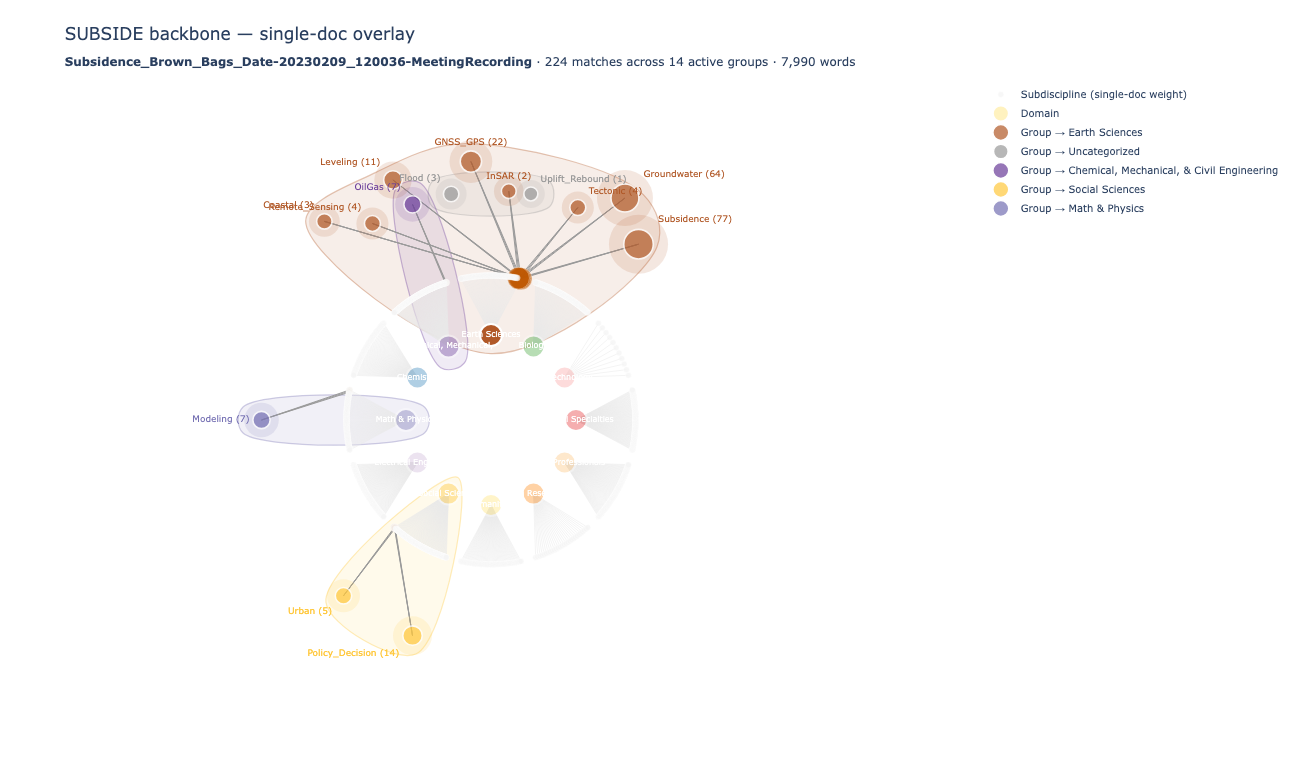

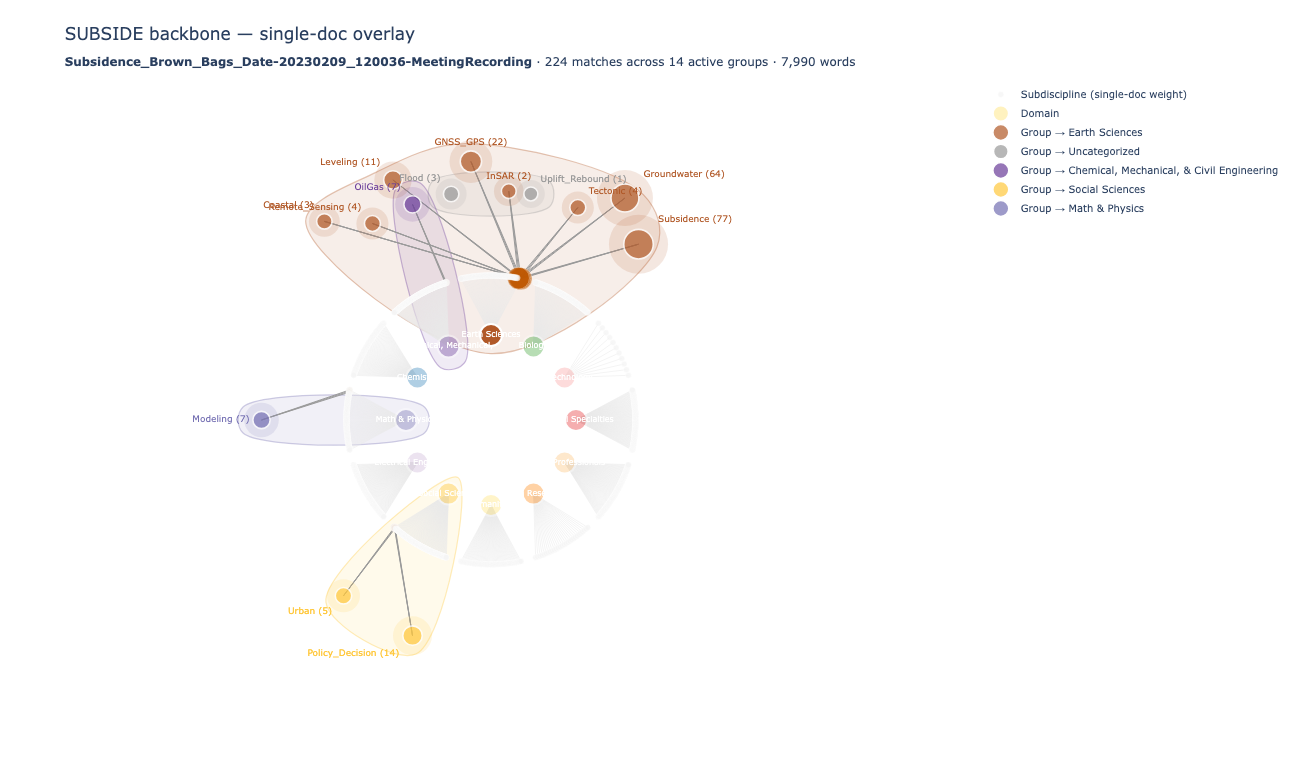

In [25]:
#SELECT
render_single_doc_overlay(2)

16 overlay documents available:

   1. Subsidence_Brown_Bag_Date-20230914_120029-MeetingRecording
      top: InSAR(36), GNSS_GPS(34), Subsidence(22)
   2. Subsidence_Brown_Bags_Date-03092028_MeetingRecording
      top: Subsidence(152), Groundwater(80), GNSS_GPS(13)
   3. Subsidence_Brown_Bags_Date-20230209_120036-MeetingRecording
      top: Subsidence(77), Groundwater(64), GNSS_GPS(22)
   4. Subsidence_Brown_Bags_Date-20230413_120246-MeetingRecording
      top: Subsidence(74), Groundwater(66), OilGas(53)
   5. Subsidence_Brown_Bags_Date-20230511_120131-MeetingRecording
      top: Subsidence(88), Coastal(49), InSAR(38)
   6. Subsidence_Brown_Bags_Date-20230608_120214-MeetingRecording
      top: Subsidence(31), Urban(25), Flood(7)
   7. Subsidence_Brown_Bags_Date-20230713_120313-MeetingRecording
      top: Subsidence(49), Leveling(43), GNSS_GPS(21)
   8. Subsidence_Brown_Bags_Date-20230810_120227-MeetingRecording
      top: Modeling(137), Subsidence(74), Groundwater(69)
   9. Subsidence_

Enter transcript number (1-16):  1.



✓ Selected [1]: Subsidence_Brown_Bag_Date-20230914_120029-MeetingRecording

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bag_Date-20230914_120029-MeetingRecording.html


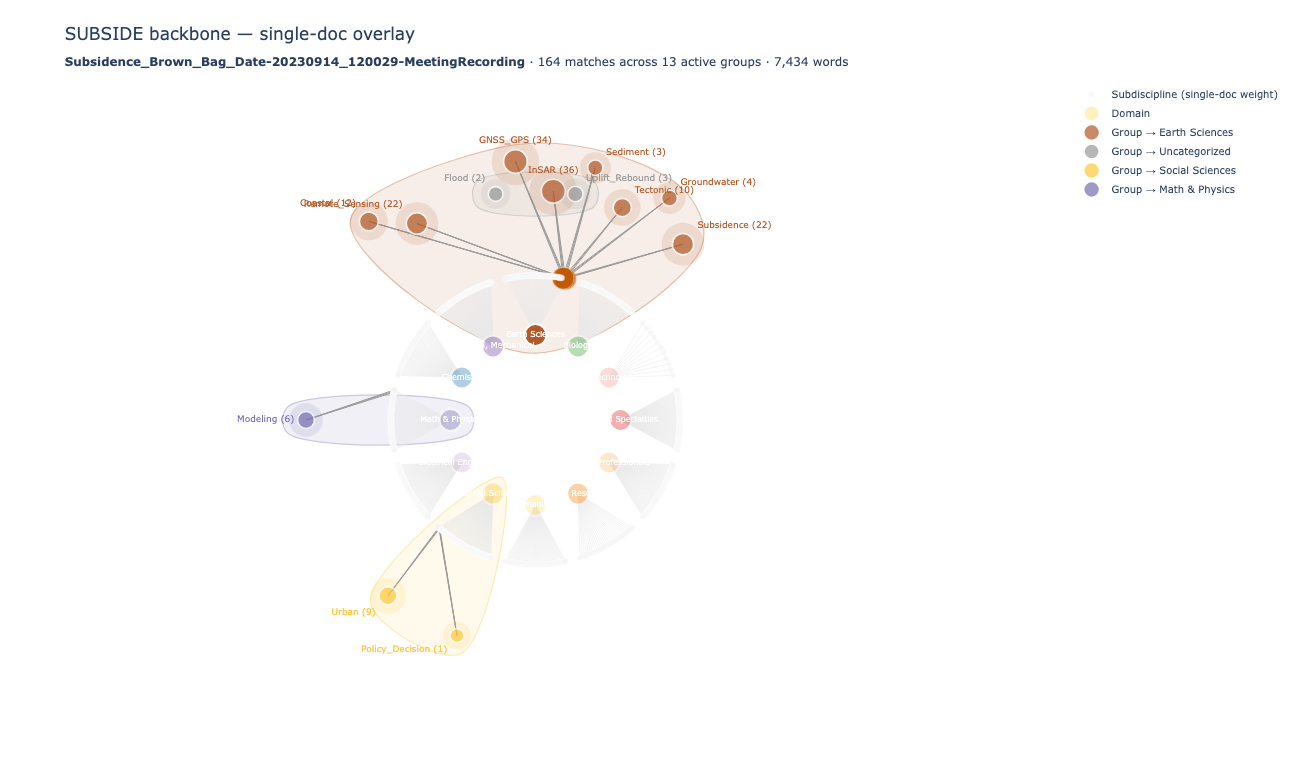

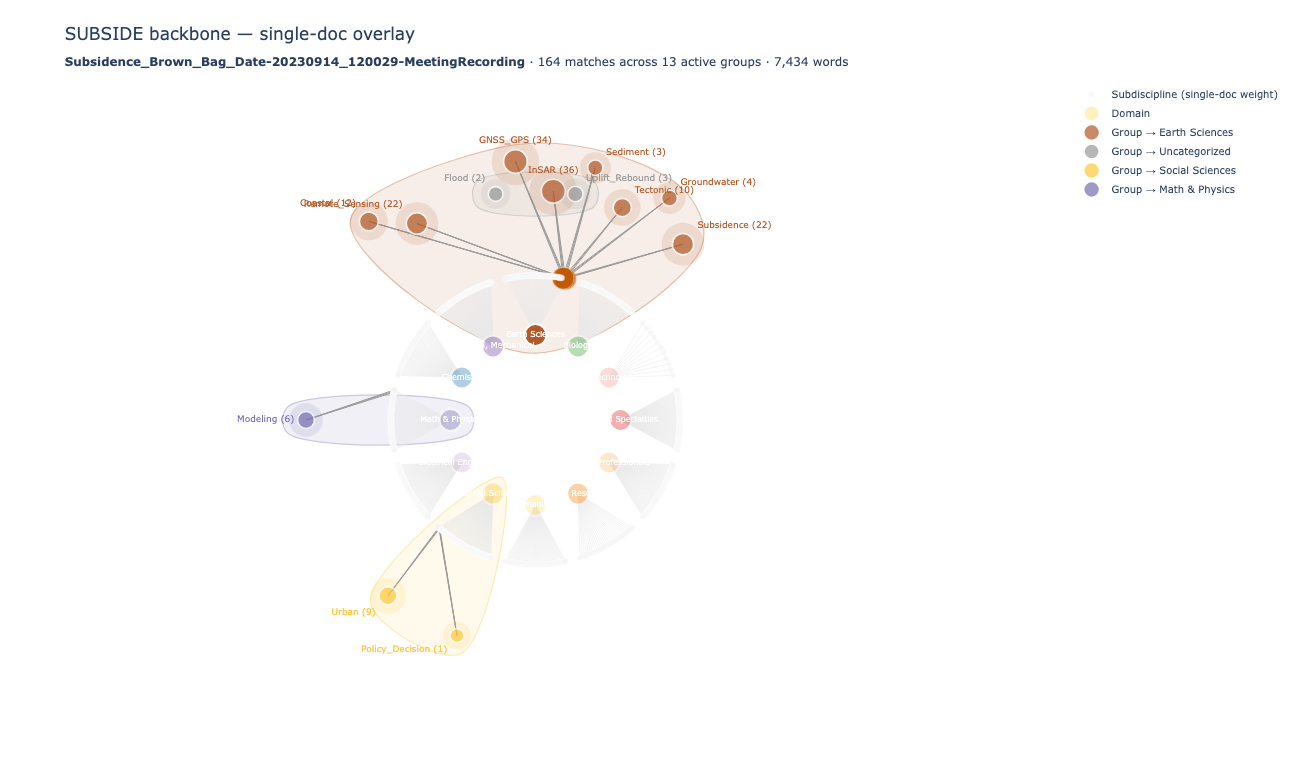

In [26]:
#Select Option Style 2
select_and_render()

In [27]:
#This will render ALL OVERLAYS
render_all_overlays()

Rendering overlays for all 16 document(s) to /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults ...

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bag_Date-20230914_120029-MeetingRecording.html
✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-03092028_MeetingRecording.html
✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230209_120036-MeetingRecording.html
✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230413_120246-MeetingRecording.html
✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230511_120131-MeetingRecording.html
✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230608_120214-Meeti

[PosixPath('/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bag_Date-20230914_120029-MeetingRecording.html'),
 PosixPath('/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-03092028_MeetingRecording.html'),
 PosixPath('/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230209_120036-MeetingRecording.html'),
 PosixPath('/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230413_120246-MeetingRecording.html'),
 PosixPath('/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230511_120131-MeetingRecording.html'),
 PosixPath('/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_single_Subsidence_Brown_Bags_Date-20230608_120214-MeetingRecording.html'),
 PosixPath('/work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/

## 6. Comparison panel — overlay vs. base

A side-by-side bar comparison: per-domain weight in the **base layer** (number
of keyword groups assigned to each domain) vs. the **overlay** (the projected
weight from §4). Useful for answering questions like "is this brown bag tilted
more towards engineering than the literature corpus is?"


Base vs Overlay distribution (% of attention per domain):
                                   domain  base_pct  overlay_pct  delta_pct
                           Earth Sciences      55.6         79.2       23.6
                           Math & Physics       5.6          8.8        3.3
                          Social Sciences      11.1          7.5       -3.6
Chemical, Mechanical, & Civil Engineering      11.1          4.4       -6.7
Electrical Engineering & Computer Science       5.6          0.1       -5.4
                            Uncategorized      11.1          0.0      -11.1


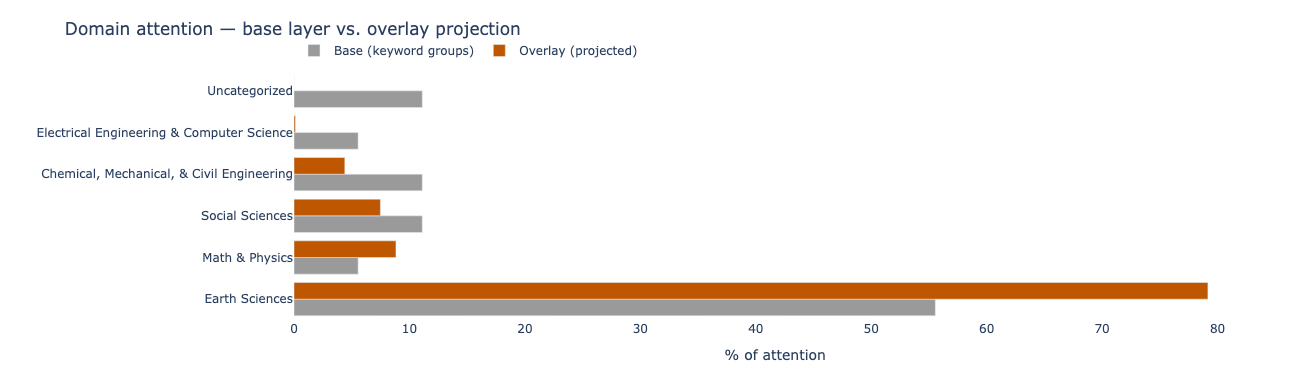


✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_vs_base.html


In [28]:
# Base distribution: number of keyword groups whose primary domain is each
base_dist = (group_mapping_df.groupby("primary_domain").size()
             .reset_index(name="base_n_groups")
             .rename(columns={"primary_domain": "domain"}))

# Overlay distribution: weight totals from §4
ov_dist = overlay_domain_totals.copy()
ov_dist["overlay_weight"] = ov_dist["weight"]
ov_dist = ov_dist.drop(columns=["weight"])

# Normalize both to percentages
base_dist["base_pct"] = 100 * base_dist["base_n_groups"] / base_dist["base_n_groups"].sum()
ov_total = ov_dist["overlay_weight"].sum() or 1.0
ov_dist["overlay_pct"] = 100 * ov_dist["overlay_weight"] / ov_total

comparison = (pd.merge(base_dist, ov_dist, on="domain", how="outer")
              .fillna(0).sort_values("overlay_pct", ascending=False))
comparison["delta_pct"] = comparison["overlay_pct"] - comparison["base_pct"]

print("Base vs Overlay distribution (% of attention per domain):")
print(comparison[["domain","base_pct","overlay_pct","delta_pct"]]
      .round(1).to_string(index=False))

# Plot
fig_cmp = go.Figure()
fig_cmp.add_trace(go.Bar(
    y=comparison["domain"], x=comparison["base_pct"],
    orientation="h", name="Base (keyword groups)",
    marker=dict(color="#9a9a9a"),
    hovertemplate="%{y}<br>Base: %{x:.1f}%<extra></extra>"))
fig_cmp.add_trace(go.Bar(
    y=comparison["domain"], x=comparison["overlay_pct"],
    orientation="h", name="Overlay (projected)",
    marker=dict(color=TACC_ORANGE),
    hovertemplate="%{y}<br>Overlay: %{x:.1f}%<extra></extra>"))
fig_cmp.update_layout(
    title="Domain attention — base layer vs. overlay projection",
    xaxis_title="% of attention",
    yaxis_title="",
    barmode="group",
    height=max(380, 28 * len(comparison) + 120),
    plot_bgcolor="white",
    margin=dict(l=240, r=40, t=70, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02,
                xanchor="left", x=0))
fig_cmp.write_html(str(OUTPUT_DIR / "overlay_vs_base.html"),
                   include_plotlyjs="cdn")
fig_cmp.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'overlay_vs_base.html'}")


## 7. Per-document breakdown

When you've loaded multiple overlay docs (e.g. all the brown bags), this heatmap
shows per-document × per-keyword-group counts — handy for spotting which session
talked the most about *Coastal* vs. *Policy_Decision* vs. *InSAR*, etc.

If you've loaded just one overlay file, the heatmap is one row tall (still
useful as a per-group bar).


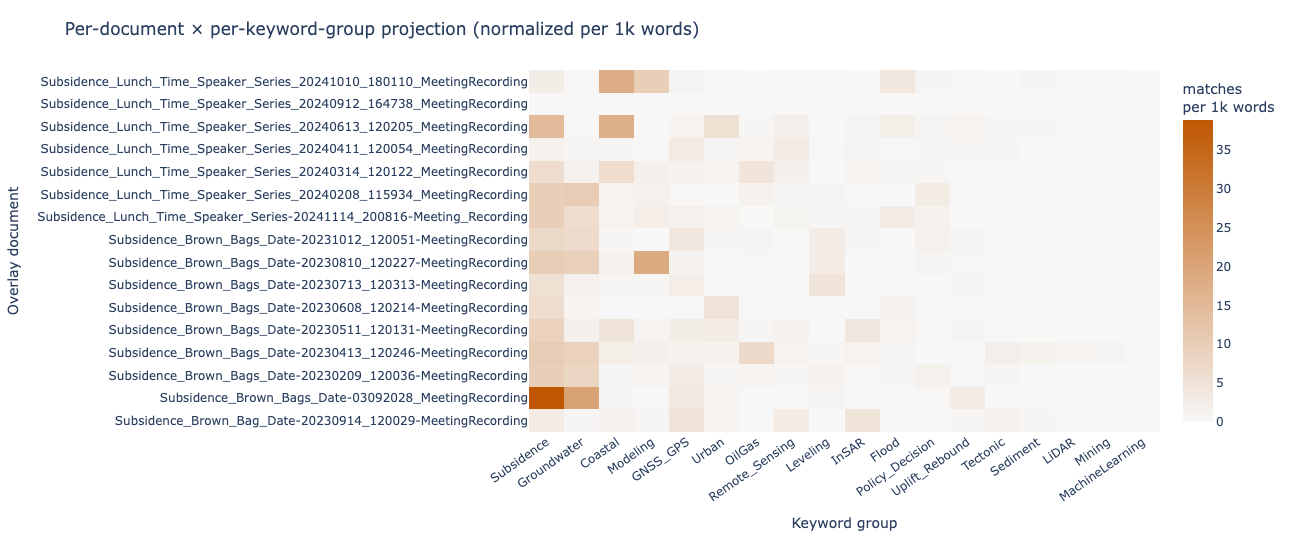

✓ Saved: /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults/overlay_per_doc_heatmap.html


In [29]:
if len(overlay_docs) >= 1 and len(overlay_doc_group_df) > 0:
    pivot = (overlay_doc_group_df
             .pivot(index="doc", columns="group", values="per_1k_words")
             .fillna(0))
    # Order columns by overall importance (descending total counts)
    col_order = (overlay_group_totals.set_index("group")["count"]
                 .reindex(pivot.columns).fillna(0)
                 .sort_values(ascending=False).index.tolist())
    pivot = pivot[col_order]

    fig_per = go.Figure(go.Heatmap(
        z=pivot.values, x=pivot.columns, y=pivot.index,
        colorscale=[[0, "#f7f7f7"], [1, TACC_ORANGE]],
        colorbar=dict(title="matches<br>per 1k words"),
        hovertemplate="Doc: %{y}<br>Group: %{x}<br>%{z:.2f}/1k words<extra></extra>"))
    fig_per.update_layout(
        title="Per-document × per-keyword-group projection (normalized per 1k words)",
        xaxis_title="Keyword group", yaxis_title="Overlay document",
        height=max(360, 22 * len(pivot) + 200),
        plot_bgcolor="white",
        margin=dict(l=220, r=40, t=70, b=120),
        xaxis=dict(tickangle=-35))
    fig_per.write_html(str(OUTPUT_DIR / "overlay_per_doc_heatmap.html"),
                       include_plotlyjs="cdn")
    fig_per.show()
    print(f"✓ Saved: {OUTPUT_DIR / 'overlay_per_doc_heatmap.html'}")
else:
    print("(no overlay data to display)")


## 8. Export

Writes everything to `OUTPUT_DIR`:

- `overlay_doc_group_counts.csv` — long-format per (doc, group) counts and per-1k normalization
- `overlay_group_totals.csv` — keyword group → overlay total
- `overlay_domain_totals.csv` — backbone domain → overlay weight
- `overlay_subdiscipline_totals.csv` — (domain, subdiscipline) → overlay weight
- `comparison_base_vs_overlay.csv` — the table behind §6
- `summary.md` — one-page Markdown digest
- Plus the three interactive HTML figures from §5–7


In [30]:
from datetime import datetime as _dt
stamp = _dt.now().strftime("%Y%m%d_%H%M%S")

overlay_doc_group_df.to_csv(OUTPUT_DIR / f"overlay_doc_group_counts_{stamp}.csv",
                            index=False, encoding="utf-8-sig")
overlay_group_totals.to_csv(OUTPUT_DIR / f"overlay_group_totals_{stamp}.csv",
                            index=False, encoding="utf-8-sig")
overlay_domain_totals.to_csv(OUTPUT_DIR / f"overlay_domain_totals_{stamp}.csv",
                             index=False, encoding="utf-8-sig")
overlay_sub_totals.to_csv(OUTPUT_DIR / f"overlay_subdiscipline_totals_{stamp}.csv",
                          index=False, encoding="utf-8-sig")
comparison.to_csv(OUTPUT_DIR / f"comparison_base_vs_overlay_{stamp}.csv",
                  index=False, encoding="utf-8-sig")

# Top-N for the summary
top_groups = overlay_group_totals.head(5).to_dict("records")
top_domains = overlay_domain_totals.head(5).to_dict("records")

summary_md = f"""# SUBSIDE Backbone Overlay — Run Summary

- **Base layer source**     : {BACKBONE_SOURCE}
- **Keyword groups loaded** : {len(KEYWORD_GROUPS)}
- **Backbone domains**      : {len(SCIENCE_BACKBONE)}
- **Overlay path**          : `{OVERLAY_PATH}`
- **Overlay docs loaded**   : {len(overlay_docs)}
- **Skipped files**         : {len(overlay_skipped)}

## Top 5 keyword groups in overlay
{overlay_group_totals.head().to_markdown(index=False)}

## Top 5 backbone domains by overlay weight
{overlay_domain_totals.head().to_markdown(index=False)}

## Largest base ↔ overlay attention gaps
{comparison.reindex(comparison['delta_pct'].abs().sort_values(ascending=False).index).head(5)[["domain","base_pct","overlay_pct","delta_pct"]].round(1).to_markdown(index=False)}

## Outputs
- `overlay_backbone.html` — radial backbone, heat-colored by overlay weight
- `overlay_vs_base.html` — base vs. overlay distribution comparison
- `overlay_per_doc_heatmap.html` — per-document × per-group projection
- `overlay_doc_group_counts_{stamp}.csv`
- `overlay_group_totals_{stamp}.csv`
- `overlay_domain_totals_{stamp}.csv`
- `overlay_subdiscipline_totals_{stamp}.csv`
- `comparison_base_vs_overlay_{stamp}.csv`
"""
(OUTPUT_DIR / f"summary_{stamp}.md").write_text(summary_md)
print(f"✓ All exports written to {OUTPUT_DIR}")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"   · {p.name}")


✓ All exports written to /work/01813/sawp33/ls6/cookbooks/SUBSIDE SciMap/OverlayResults
   · .ipynb_checkpoints
   · comparison_base_vs_overlay_20260511_014444.csv
   · comparison_base_vs_overlay_20260511_020140.csv
   · comparison_base_vs_overlay_20260512_063716.csv
   · overlay_backbone.html
   · overlay_doc_group_counts_20260511_014444.csv
   · overlay_doc_group_counts_20260511_020140.csv
   · overlay_doc_group_counts_20260512_063716.csv
   · overlay_domain_totals_20260511_014444.csv
   · overlay_domain_totals_20260511_020140.csv
   · overlay_domain_totals_20260512_063716.csv
   · overlay_group_totals_20260511_014444.csv
   · overlay_group_totals_20260511_020140.csv
   · overlay_group_totals_20260512_063716.csv
   · overlay_per_doc_heatmap.html
   · overlay_single_Subsidence_Brown_Bag_Date-20230914_120029-MeetingRecording.html
   · overlay_single_Subsidence_Brown_Bags_Date-03092028_MeetingRecording.html
   · overlay_single_Subsidence_Brown_Bags_Date-20230209_120036-MeetingRecording.

---

## What this notebook does, at a glance

| Section | Role |
|---|---|
| 1 | Setup, paths, dependency check |
| 2 | Load base layer = `KEYWORD_GROUPS` + science backbone (from prior notebooks or inline fallback) |
| 3 | Load overlay corpus (single file or directory, supports `.txt` / `.md` / `.docx` / `.json` / `.pdf`) |
| 4 | Project overlay onto backbone — per-doc, per-group, per-domain, per-subdiscipline weights |
| 5 | **Radial backbone visualization** — same Klavans/Boyack layout as the main notebook §7, recolored to show overlay heat, with overlay docs as outer-ring nodes |
| 6 | **Comparison panel** — base distribution vs. overlay distribution (% of attention per domain) |
| 7 | **Per-document × per-group heatmap** — for multi-doc overlays |
| 8 | Exports — CSV tables + HTML figures + Markdown summary |

### Customizing

- **§1** — point `OVERLAY_PATH` at your file or folder; flip `OVERLAY_GLOB_PATTERNS` to narrow
- **§2** — edit `INLINE_KEYWORD_GROUPS` if no saved keyword groups exist yet
- **§4** — `count_group_in_text` does word-boundary regex for single-word terms,
  substring for multi-word terms. Both are case-insensitive.
- **§5** — `R_DOMAIN`, `R_SUB`, `R_GROUP`, `R_OVERLAY` control the four concentric rings;
  `TACC_ORANGE` is the heat color

### Typical workflows

| Goal | Setup |
|---|---|
| One brown-bag transcript projected onto SUBSIDE literature | `OVERLAY_PATH = /path/to/Subsidence_Brown_Bag_*.json` |
| All brown bags compared with the literature backbone | `OVERLAY_PATH = /mnt/project`, `OVERLAY_GLOB_PATTERNS = ["*Brown_Bag*"]` |
| Stakeholder interview vs. the backbone | `OVERLAY_PATH = /path/to/Call_with_Shirley_Wade_*.docx` |
| A regional groundwater management plan vs. backbone | `OVERLAY_PATH = /path/to/GMA_plan.pdf` |
| Two cohorts compared (run twice with different `OVERLAY_PATH`s, save `comparison_*.csv`, diff) | per-run pattern |
